# 🏋️ 01_train_vision.ipynb — MobileNetV2 vs EfficientNetB0
**Run on PC / Laptop with GPU.**

يدرّب النموذجين بنفس الشروط ويقارن بينهم، ثم يحفظ أفضل واحد كـ TFLite للـ Pi.

```
Flow:
  dataset/ → Augment → Phase1 (head only) → Phase2 (fine-tune)
           → Evaluate → Compare → Export best → models/best_vision.tflite
```

## Cell 1 — Imports & GPU Check

In [14]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow :', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU        :', gpus if gpus else 'None — using CPU')

TensorFlow : 2.19.0
GPU        : None — using CPU


## Cell 2 — Config

In [15]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_DIR = 'dataset/train'
VAL_DIR   = 'dataset/val'
TEST_DIR  = 'dataset/test'

os.makedirs('models', exist_ok=True)

MOBILE_KERAS   = 'models/mobilenet_model.keras'
EFFNET_KERAS   = 'models/efficientnet_model.keras'
BEST_TFLITE    = 'models/best_vision.tflite'   # ← يُستخدم في 03 و 04
BEST_META      = 'models/best_vision_meta.json'
LABELS_PATH    = 'models/labels.json'

# ── Image ─────────────────────────────────────────────────────────────────────
IMG_H, IMG_W = 224, 224

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE      = 32
EPOCHS_HEAD     = 10
EPOCHS_FINETUNE = 10
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-5
UNFREEZE_MOBILE = 30   # آخر N layer في MobileNetV2
UNFREEZE_EFF    = 20   # آخر N layer في EfficientNetB0

print('Config loaded ✅')

Config loaded ✅


## Cell 3 — Data Generators

In [16]:
# ── Augmentation (shared) ────────────────────────────────────────────────────
_aug_args = dict(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
)

# MobileNetV2 — يحتاج rescale
mobile_train_gen = ImageDataGenerator(rescale=1./255, **_aug_args)
mobile_val_gen   = ImageDataGenerator(rescale=1./255)

# EfficientNetB0 — له preprocess_input خاص بيه
eff_preprocess = tf.keras.applications.efficientnet.preprocess_input
eff_train_gen  = ImageDataGenerator(preprocessing_function=eff_preprocess, **_aug_args)
eff_val_gen    = ImageDataGenerator(preprocessing_function=eff_preprocess)

def make_flow(gen, directory, shuffle=True):
    return gen.flow_from_directory(
        directory, target_size=(IMG_H, IMG_W),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=shuffle, seed=42,
    )

mobile_train = make_flow(mobile_train_gen, TRAIN_DIR)
mobile_val   = make_flow(mobile_val_gen,   VAL_DIR,  shuffle=False)
mobile_test  = make_flow(mobile_val_gen,   TEST_DIR,  shuffle=False)

eff_train = make_flow(eff_train_gen, TRAIN_DIR)
eff_val   = make_flow(eff_val_gen,   VAL_DIR,  shuffle=False)
eff_test  = make_flow(eff_val_gen,   TEST_DIR,  shuffle=False)

LABELS     = list(mobile_train.class_indices.keys())
NUM_CLASSES = len(LABELS)

# حفظ labels.json
idx2label = {str(v): k for k, v in mobile_train.class_indices.items()}
with open(LABELS_PATH, 'w') as f:
    json.dump(idx2label, f, indent=2)

print(f'Classes ({NUM_CLASSES}) : {LABELS}')
print(f'Train batches   : {len(mobile_train)}')
print(f'labels.json     : {LABELS_PATH} ✅')

Found 350 images belonging to 5 classes.
Found 78 images belonging to 5 classes.
Found 76 images belonging to 5 classes.
Found 350 images belonging to 5 classes.
Found 78 images belonging to 5 classes.
Found 76 images belonging to 5 classes.
Classes (5) : ['ambezim', 'brufen', 'cataflam', 'ketofan', 'trimed_flu']
Train batches   : 11
labels.json     : models/labels.json ✅


## Cell 4 — Helper: Build & Train Function

In [17]:
def build_and_train(arch_name, base_factory, base_kwargs,
                    train_flow, val_flow, unfreeze_n, save_path):
    """
    بيبني نموذج transfer learning من أي base وبيدربه في مرحلتين.
    Returns: (model, history_head, history_finetune, test_acc)
    """
    print(f'\n{"="*54}')
    print(f'  🚀  Training: {arch_name}')
    print(f'{"="*54}')

    # ── Phase 1: Head only ───────────────────────────────────────────────────
    base = base_factory(
        input_shape=(IMG_H, IMG_W, 3),
        include_top=False, weights='imagenet',
        **base_kwargs
    )
    base.trainable = False

    inp = layers.Input(shape=(IMG_H, IMG_W, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = models.Model(inp, out)

    model.compile(
        optimizer=optimizers.Adam(LR_HEAD),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    cb_head = [
        callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
    ]

    print(f'  Phase 1: head only ({EPOCHS_HEAD} epochs max)...')
    hist_head = model.fit(
        train_flow, epochs=EPOCHS_HEAD,
        validation_data=val_flow,
        callbacks=cb_head, verbose=1,
    )

    # ── Phase 2: Fine-tune ────────────────────────────────────────────────────
    base.trainable = True
    for layer in base.layers[:-unfreeze_n]:
        layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(LR_FINETUNE),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    cb_fine = [
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(save_path, save_best_only=True, verbose=1),
        callbacks.ReduceLROnPlateau(patience=2, factor=0.3, verbose=1),
    ]

    print(f'  Phase 2: fine-tune last {unfreeze_n} layers ({EPOCHS_FINETUNE} epochs max)...')
    hist_fine = model.fit(
        train_flow, epochs=EPOCHS_FINETUNE,
        validation_data=val_flow,
        callbacks=cb_fine, verbose=1,
    )

    return model, hist_head, hist_fine

## Cell 5 — Train MobileNetV2

In [18]:
mobile_model, mobile_hist_h, mobile_hist_f = build_and_train(
    arch_name     = 'MobileNetV2',
    base_factory  = MobileNetV2,
    base_kwargs   = {},
    train_flow    = mobile_train,
    val_flow      = mobile_val,
    unfreeze_n    = UNFREEZE_MOBILE,
    save_path     = MOBILE_KERAS,
)


  🚀  Training: MobileNetV2
  Phase 1: head only (10 epochs max)...
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.4246 - loss: 1.6601 - val_accuracy: 0.8846 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.8755 - loss: 0.3401 - val_accuracy: 0.9615 - val_loss: 0.2698 - learning_rate: 0.0010
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9266 - loss: 0.2206 - val_accuracy: 0.9744 - val_loss: 0.1593 - learning_rate: 0.0010
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9562 - loss: 0.1646 - val_accuracy: 0.9744 - val_loss: 0.1236 - learning_rate: 0.0010
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9491 - loss: 0.1425 - val_accuracy: 1.0000 - val_loss: 0.0687 - learning_rate: 0.0010
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9898 - loss: 0.0556 - val_accuracy: 1.0000 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━

## Cell 6 — Train EfficientNetB0

In [19]:
eff_model, eff_hist_h, eff_hist_f = build_and_train(
    arch_name     = 'EfficientNetB0',
    base_factory  = EfficientNetB0,
    base_kwargs   = {},
    train_flow    = eff_train,
    val_flow      = eff_val,
    unfreeze_n    = UNFREEZE_EFF,
    save_path     = EFFNET_KERAS,
)


  🚀  Training: EfficientNetB0
  Phase 1: head only (10 epochs max)...
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4547 - loss: 1.4998 - val_accuracy: 0.8462 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.8548 - loss: 0.3822 - val_accuracy: 0.9103 - val_loss: 0.4124 - learning_rate: 0.0010
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9243 - loss: 0.2051 - val_accuracy: 1.0000 - val_loss: 0.2354 - learning_rate: 0.0010
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9694 - loss: 0.1082 - val_accuracy: 1.0000 - val_loss: 0.1429 - learning_rate: 0.0010
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9641 - loss: 0.1141 - val_accuracy: 1.0000 - val_loss: 0.0924 - learning_rate: 0.0010
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9729 - loss: 0.0570 - val_accuracy: 1.0000 - val_loss: 0.0695 - learning_rate: 0.0010
Epoch 7/10
11/11 ━━━━━━━━━━━━

## Cell 7 — Evaluate on Test Set

In [20]:
def evaluate_model(model, test_flow, model_name):
    test_flow.reset()
    loss, acc = model.evaluate(test_flow, verbose=0)
    print(f'{model_name:18} — Test Acc: {acc:.4f}  Loss: {loss:.4f}')

    # Classification report
    test_flow.reset()
    y_pred = np.argmax(model.predict(test_flow, verbose=0), axis=1)
    y_true = test_flow.classes
    print(classification_report(y_true, y_pred, target_names=LABELS))
    return acc

print('\n── Test Results ─────────────────────────────────────')
mobile_acc = evaluate_model(mobile_model, mobile_test, 'MobileNetV2')
eff_acc    = evaluate_model(eff_model,    eff_test,    'EfficientNetB0')


── Test Results ─────────────────────────────────────
MobileNetV2        — Test Acc: 0.9737  Loss: 0.0359
              precision    recall  f1-score   support

     ambezim       0.92      1.00      0.96        11
      brufen       1.00      0.93      0.97        15
    cataflam       1.00      1.00      1.00        16
     ketofan       0.95      1.00      0.98        21
  trimed_flu       1.00      0.92      0.96        13

    accuracy                           0.97        76
   macro avg       0.97      0.97      0.97        76
weighted avg       0.98      0.97      0.97        76



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


EfficientNetB0     — Test Acc: 0.9868  Loss: 0.0424
              precision    recall  f1-score   support

     ambezim       0.92      1.00      0.96        11
      brufen       1.00      1.00      1.00        15
    cataflam       1.00      0.94      0.97        16
     ketofan       1.00      1.00      1.00        21
  trimed_flu       1.00      1.00      1.00        13

    accuracy                           0.99        76
   macro avg       0.98      0.99      0.98        76
weighted avg       0.99      0.99      0.99        76



## Cell 8 — Confusion Matrices

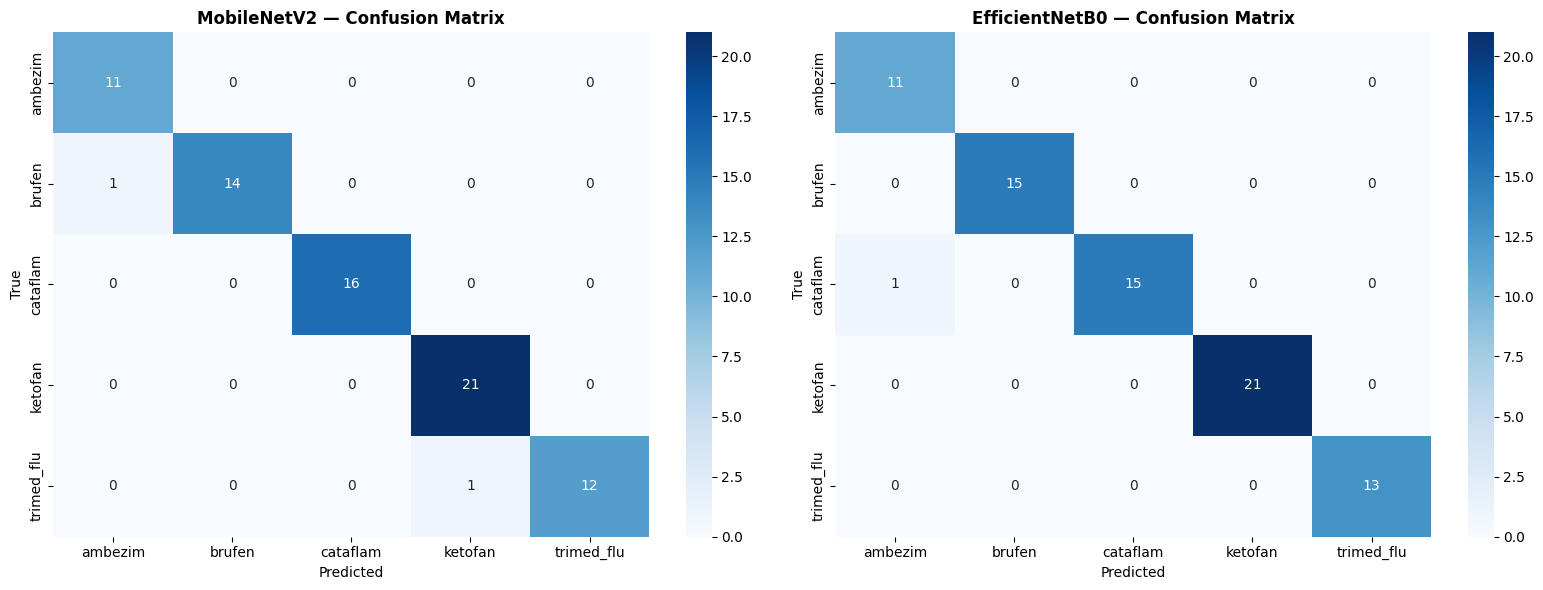

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, flow, name in [
    (axes[0], mobile_model, mobile_test, 'MobileNetV2'),
    (axes[1], eff_model,    eff_test,    'EfficientNetB0'),
]:
    flow.reset()
    y_pred = np.argmax(model.predict(flow, verbose=0), axis=1)
    cm = confusion_matrix(flow.classes, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('models/vision_confusion_matrices.png', dpi=150)
plt.show()

## Cell 9 — Training Curves Comparison

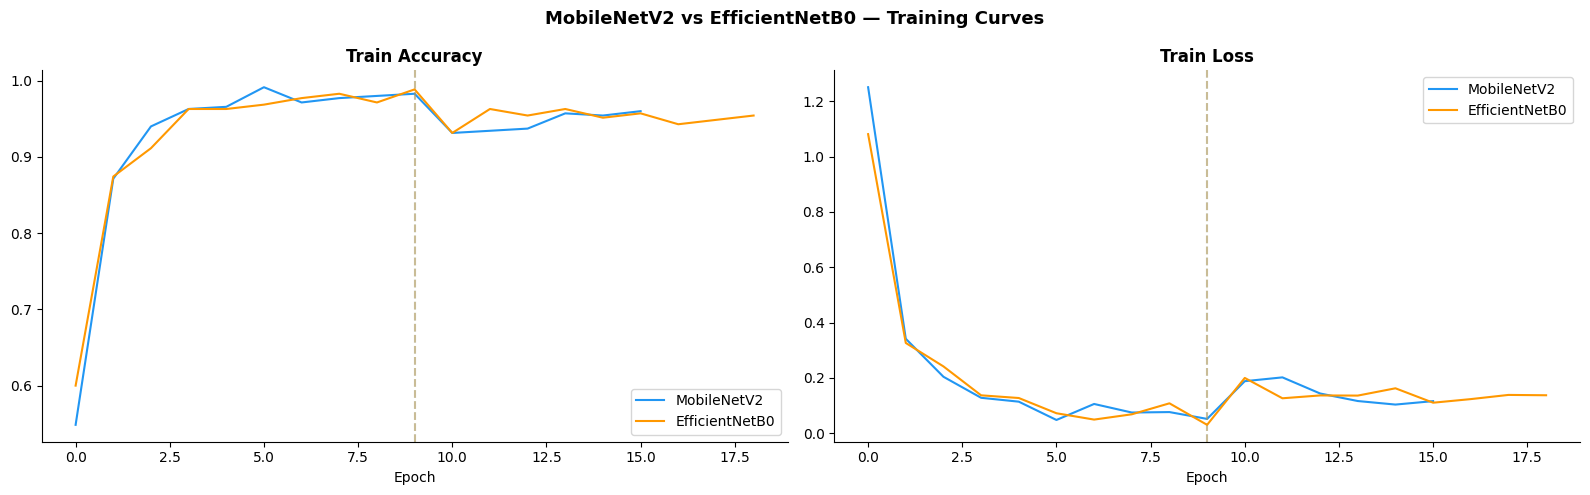

In [22]:
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in zip(axes, ['accuracy', 'loss']):
    for name, h1, h2, color in [
        ('MobileNetV2',    mobile_hist_h, mobile_hist_f, '#2196F3'),
        ('EfficientNetB0', eff_hist_h,    eff_hist_f,    '#FF9800'),
    ]:
        vals = combine_history(h1, h2, metric)
        ax.plot(vals, label=name, color=color)
        # خط فاصل بين Phase 1 و Phase 2
        ax.axvline(len(h1.history[metric])-1, color=color, linestyle='--', alpha=0.4)
    ax.set_title(f'Train {metric.capitalize()}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('MobileNetV2 vs EfficientNetB0 — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('models/vision_training_curves.png', dpi=150)
plt.show()

## Cell 10 — Pick Best & Export TFLite

In [23]:
print('\n' + '='*50)
print('   VISION MODEL COMPARISON')
print('='*50)
print(f'  MobileNetV2    : {mobile_acc:.4f}')
print(f'  EfficientNetB0 : {eff_acc:.4f}')

if mobile_acc >= eff_acc:
    best_model   = mobile_model
    best_name    = 'MobileNetV2'
    best_acc     = mobile_acc
    preprocess_type = 'mobilenet'   # يُستخدم في infer
else:
    best_model   = eff_model
    best_name    = 'EfficientNetB0'
    best_acc     = eff_acc
    preprocess_type = 'efficientnet'

print(f'\n  🏆 Best: {best_name} ({best_acc:.4f})')
print('='*50)

# ── Export TFLite ────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(BEST_TFLITE, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(BEST_TFLITE) / 1e6
print(f'\n  TFLite saved  : {BEST_TFLITE}  ({size_mb:.1f} MB) ✅')

# ── حفظ meta للـ notebooks التانية ──────────────────────────────────────────
meta = {
    'best_model'      : best_name,
    'best_acc'        : float(best_acc),
    'mobile_acc'      : float(mobile_acc),
    'eff_acc'         : float(eff_acc),
    'preprocess_type' : preprocess_type,
    'labels'          : LABELS,
    'tflite_path'     : BEST_TFLITE,
    'labels_path'     : LABELS_PATH,
}
with open(BEST_META, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'  Meta saved    : {BEST_META} ✅')
print('\n  ✅ Ready for 03_voice_controller.ipynb and 04_infer_pi.ipynb')


   VISION MODEL COMPARISON
  MobileNetV2    : 0.9737
  EfficientNetB0 : 0.9868

  🏆 Best: EfficientNetB0 (0.9868)
INFO:tensorflow:Assets written to: /var/folders/2m/b7fjj_3560s01zcyk5864gm80000gn/T/tmpi4j9d9gb/assets


INFO:tensorflow:Assets written to: /var/folders/2m/b7fjj_3560s01zcyk5864gm80000gn/T/tmpi4j9d9gb/assets


Saved artifact at '/var/folders/2m/b7fjj_3560s01zcyk5864gm80000gn/T/tmpi4j9d9gb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_727')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  6361387792: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  13075686864: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  6292603536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6292607376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6292614864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6292611792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6292609488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6292616016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6292617168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6292615056: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1778804924.972517  938790 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778804924.972805  938790 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-05-15 03:28:44.975410: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/b7fjj_3560s01zcyk5864gm80000gn/T/tmpi4j9d9gb
2026-05-15 03:28:44.985070: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-05-15 03:28:44.985091: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/2m/b7fjj_3560s01zcyk5864gm80000gn/T/tmpi4j9d9gb
I0000 00:00:1778804925.093190  938790 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-05-15 03:28:45.111720: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-05-15 03:28:45.681301: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder